# Beverage Sales Analysis

## 1. Importing Data

Data Source : https://www.kaggle.com/datasets/sebastianwillmann/beverage-sales

In [1]:
# %pip install numpy seaborn matplotlib pandas
 # %pip install -U scikit-learn
# %pip install utilsforecast
# %pip install pmdarima
# %pip install statsmodels

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression 
from utilsforecast.plotting import plot_series


pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
df = pd.read_csv('synthetic_beverage_sales_data.csv')

## 2. Data Preperation

In [3]:
df.head()

,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date
0,ORD1,CUS1496,B2B,Vio Wasser,Water,1.66,53,0.10,79.18,Baden-Württemberg,2023-08-23
1,ORD1,CUS1496,B2B,Evian,Water,1.56,90,0.10,126.36,Baden-Württemberg,2023-08-23
2,ORD1,CUS1496,B2B,Sprite,Soft Drinks,1.17,73,0.05,81.14,Baden-Württemberg,2023-08-23
3,ORD1,CUS1496,B2B,Rauch Multivitamin,Juices,3.22,59,0.10,170.98,Baden-Württemberg,2023-08-23
4,ORD1,CUS1496,B2B,Gerolsteiner,Water,0.87,35,0.10,27.40,Baden-Württemberg,2023-08-23


In [4]:
#df[['Order_Date']].sort_values(by=['Order_Date']).tail()
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['YearMonth'] = df['Order_Date'].dt.to_period('M')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8999910 entries, 0 to 8999909
Data columns (total 12 columns):
 #   Column         Dtype         
---  ------         -----         
 0   Order_ID       object        
 1   Customer_ID    object        
 2   Customer_Type  object        
 3   Product        object        
 4   Category       object        
 5   Unit_Price     float64       
 6   Quantity       int64         
 7   Discount       float64       
 8   Total_Price    float64       
 9   Region         object        
 10  Order_Date     datetime64[ns]
 11  YearMonth      period[M]     
dtypes: datetime64[ns](1), float64(3), int64(1), object(6), period[M](1)
memory usage: 824.0+ MB


In [6]:
df.describe()

,Unit_Price,Quantity,Discount,Total_Price,Order_Date
count,8999910.00,8999910.00,8999910.00,8999910.00,8999910
mean,5.82,23.14,0.03,130.74,2022-07-01 16:18:18.126182144
min,0.32,1.00,0.00,0.30,2021-01-01 00:00:00
25%,1.05,6.00,0.00,8.40,2021-10-01 00:00:00
50%,1.75,11.00,0.00,21.14,2022-07-02 00:00:00
75%,3.21,30.00,0.05,69.49,2023-04-01 00:00:00
max,169.53,100.00,0.15,14295.30,2023-12-30 00:00:00
std,14.70,26.89,0.04,509.69,NaN


In [7]:
df.isna().sum()

Order_ID         0
Customer_ID      0
Customer_Type    0
Product          0
Category         0
Unit_Price       0
Quantity         0
Discount         0
Total_Price      0
Region           0
Order_Date       0
YearMonth        0
dtype: int64

In [8]:
df.head()

,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date,YearMonth
0,ORD1,CUS1496,B2B,Vio Wasser,Water,1.66,53,0.10,79.18,Baden-Württemberg,2023-08-23,2023-08
1,ORD1,CUS1496,B2B,Evian,Water,1.56,90,0.10,126.36,Baden-Württemberg,2023-08-23,2023-08
2,ORD1,CUS1496,B2B,Sprite,Soft Drinks,1.17,73,0.05,81.14,Baden-Württemberg,2023-08-23,2023-08
3,ORD1,CUS1496,B2B,Rauch Multivitamin,Juices,3.22,59,0.10,170.98,Baden-Württemberg,2023-08-23,2023-08
4,ORD1,CUS1496,B2B,Gerolsteiner,Water,0.87,35,0.10,27.40,Baden-Württemberg,2023-08-23,2023-08


In [9]:
df.Customer_ID.nunique()

10000

In [10]:
df['Total_Price'].loc[(df['Product'] == 'Moët & Chandon') & (df['YearMonth'] == pd.Period('2021-02'))].sum()

np.float64(4154968.8)

In [11]:
df.columns

Index(['Order_ID', 'Customer_ID', 'Customer_Type', 'Product', 'Category',
       'Unit_Price', 'Quantity', 'Discount', 'Total_Price', 'Region',
       'Order_Date', 'YearMonth'],
      dtype='object')

# 3. EDA

In [12]:
total_sales_revenue = df['Total_Price'].sum()
total_sales_revenue

np.float64(1176681163.3500004)

In [13]:
total_orders = df['Order_ID'].count()
total_orders

np.int64(8999910)

In [14]:
average_order_value = total_sales_revenue / total_orders
print("Average Order Value:", average_order_value)

Average Order Value: 130.74365891992258


## - 3.1 Sales Performace Report
- Net Revenue and Total Volume By Product and Category
- Net Revenue by Region, B2B and B2C customers

#### -> 3.1.1 Revenue by Product (2021 - 2023)

In [15]:
rev_by_product = df.pivot_table(values = 'Total_Price', index = 'Product', aggfunc = {'Total_Price' : "sum"}, sort=True)

In [16]:
rev_by_product[['Total_Price']].astype('float64').sort_values(by=['Total_Price'], ascending=False).rename(columns={'Total_Price':'Net_Revenue_by_Product'})

,Net_Revenue_by_Product
Product,
Veuve Clicquot,202581898.42
Moët & Chandon,175088086.21
Johnnie Walker,97261800.90
Jack Daniels,95881002.87
Tanqueray,86143655.59
Bacardi,58467504.37
Havana Club,58046964.24
Sauvignon Blanc,23319175.06
Cranberry Juice,23044830.98


#### ->  3.1.2 Revenue by Category (2021-2023)

In [17]:
revenue_by_category = df.pivot_table(values = 'Total_Price', index = 'Category', aggfunc={'Total_Price': 'sum'})

In [18]:
revenue_by_category = revenue_by_category[['Total_Price']].astype('int64').sort_values(by=['Total_Price'], ascending=False).rename(columns={'Total_Price':'Net_Revenue_by_Category'})

In [19]:
revenue_by_category

,Net_Revenue_by_Category
Category,
Alcoholic Beverages,911797919
Juices,133167848
Soft Drinks,82802542
Water,48912852


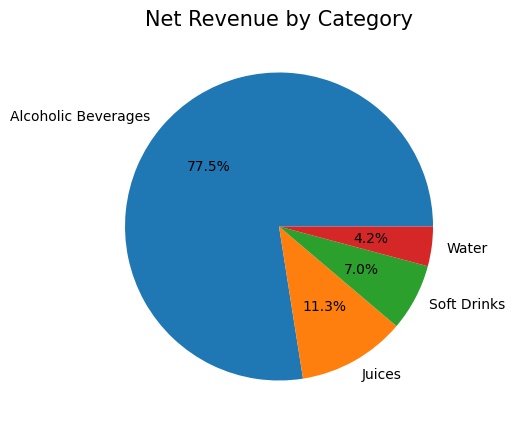

In [20]:
plt.figure(figsize = (5,5))
plt.pie(revenue_by_category['Net_Revenue_by_Category'], labels = ['Alcoholic Beverages','Juices', 'Soft Drinks', 'Water'], autopct = '%1.1f%%' )
plt.title('Net Revenue by Category', fontsize=15)
plt.show()

#### -> 3.1.3 Revenue by Product and Category Plot

In [21]:
rev_by_product_and_category = df.pivot_table(values = ['Total_Price'], index = ['Product', 'Category'], aggfunc = {'Total_Price' : "sum"}, sort=True)

In [22]:
rev_by_product_and_category = rev_by_product_and_category[['Total_Price']].astype('int64').sort_values(by=['Total_Price'], ascending=False).rename(columns={'Total_Price':'Net_Revenue_by_Product_and_Category'})

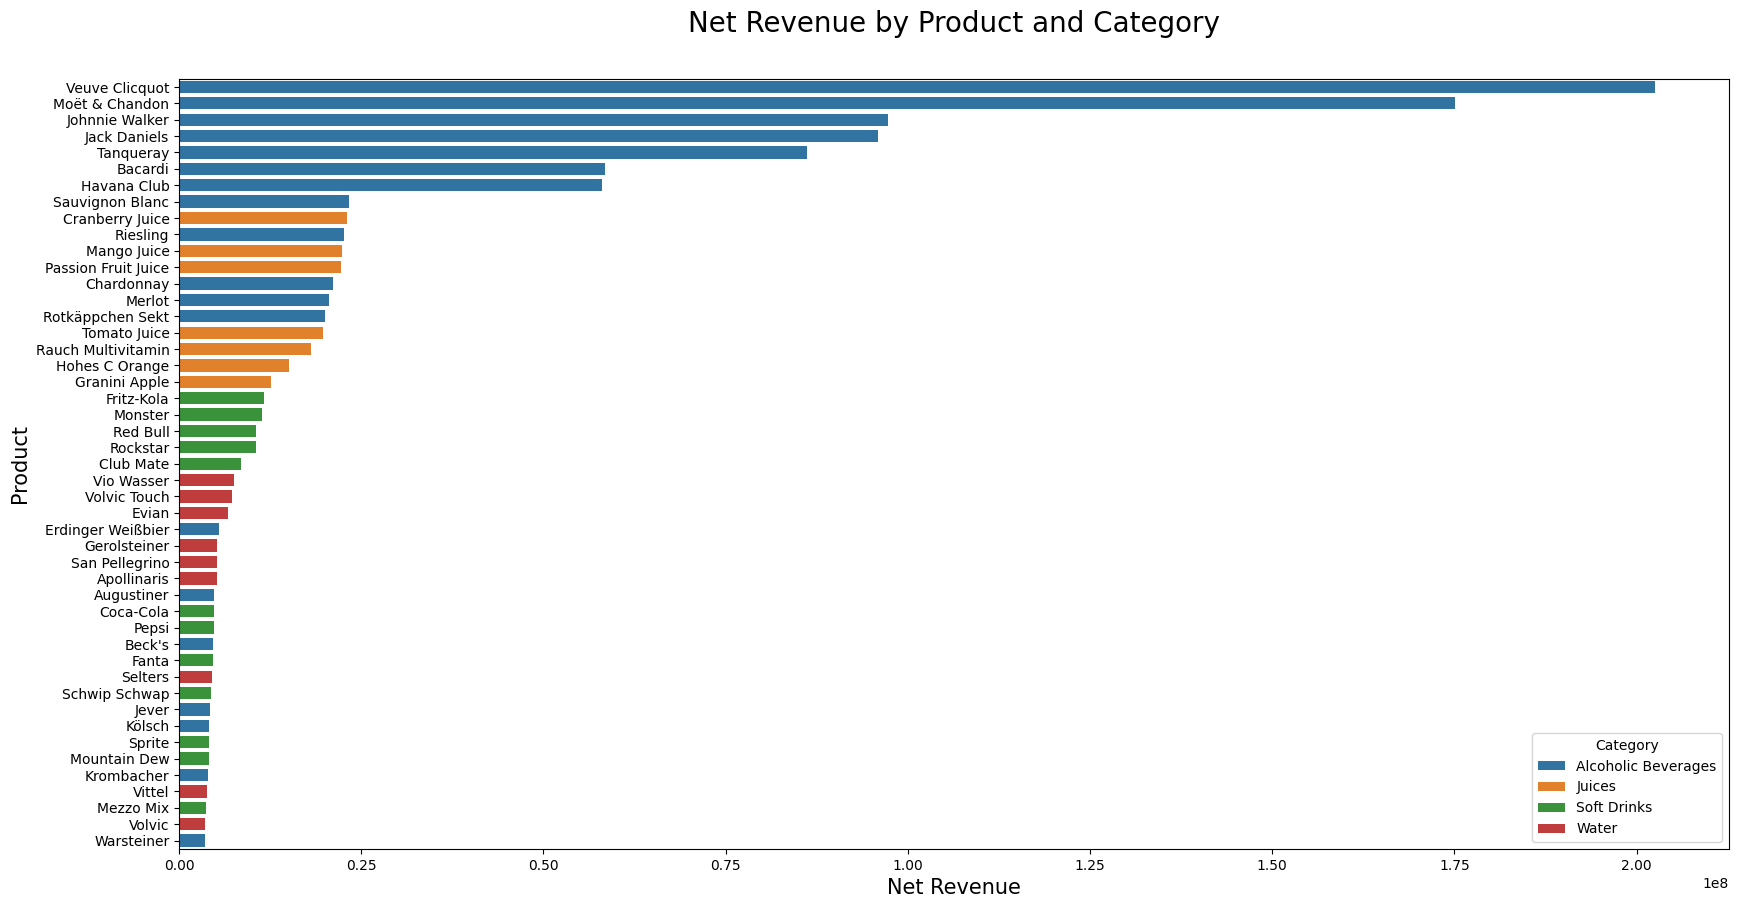

In [23]:
plt.figure(figsize = (20,10))
net_rev_plot = sns.barplot(rev_by_product_and_category, y="Product",x="Net_Revenue_by_Product_and_Category", hue="Category", width=0.75)
net_rev_plot.set_xlabel('Net Revenue', fontsize=15)
net_rev_plot.set_ylabel('Product', fontsize=15)
plt.title('Net Revenue by Product and Category', y=1.05, fontsize=20)
plt.show()

## - 3.2 Volume by Product and Category

#### -> 3.2.1 Volume by Product (2021-2023)

In [24]:
volume_by_product = df.pivot_table(values='Quantity', index='Product', aggfunc={'Quantity': 'sum'}).sort_values(by=['Quantity'], ascending=False)

In [25]:
volume_by_product

,Quantity
Product,
Hohes C Orange,7794189
Tomato Juice,7395329
Granini Apple,7393212
Cranberry Juice,7380841
Passion Fruit Juice,7372320
Rauch Multivitamin,7361875
Mango Juice,7349108
San Pellegrino,5934719
Vittel,5921086


#### -> 3.2.2 Volume by Category (2021-2023)

In [26]:
volume_by_category = df.pivot_table(values='Quantity', index='Category', aggfunc={'Quantity': 'sum'}).sort_values(by=['Quantity'], ascending=False)

In [27]:
volume_by_category

,Quantity
Category,
Alcoholic Beverages,52109641
Water,52080896
Juices,52046874
Soft Drinks,52003710


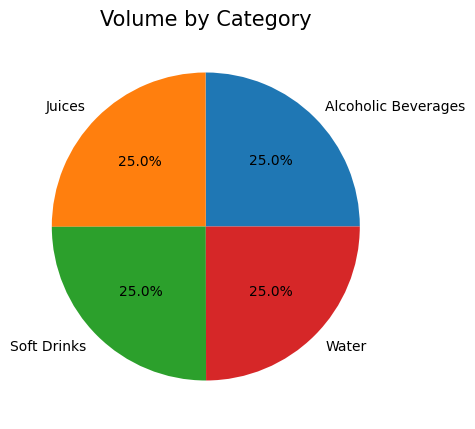

In [28]:
plt.figure(figsize = (5,5))
plt.pie(volume_by_category['Quantity'], labels = ['Alcoholic Beverages','Juices', 'Soft Drinks', 'Water'], autopct = '%1.1f%%' )
plt.title('Volume by Category', fontsize=15)
plt.show()

- this metric will be interpreted as noise and unreleastic in the real world, realistically volume by catagorey would not be evenly distributed.

#### -> 3.2.3 Volume by Product and Category

In [29]:
volume_by_product_and_category = df.pivot_table(values = ['Quantity'], index = ['Product', 'Category'], aggfunc = {'Quantity' : "sum"}, sort=True)

In [30]:
volume_by_product_and_category = volume_by_product_and_category[['Quantity']].astype('int64').sort_values(by=['Quantity'], ascending=False).rename(columns={'Quantity':'Volume_by_Product_and_Category'})

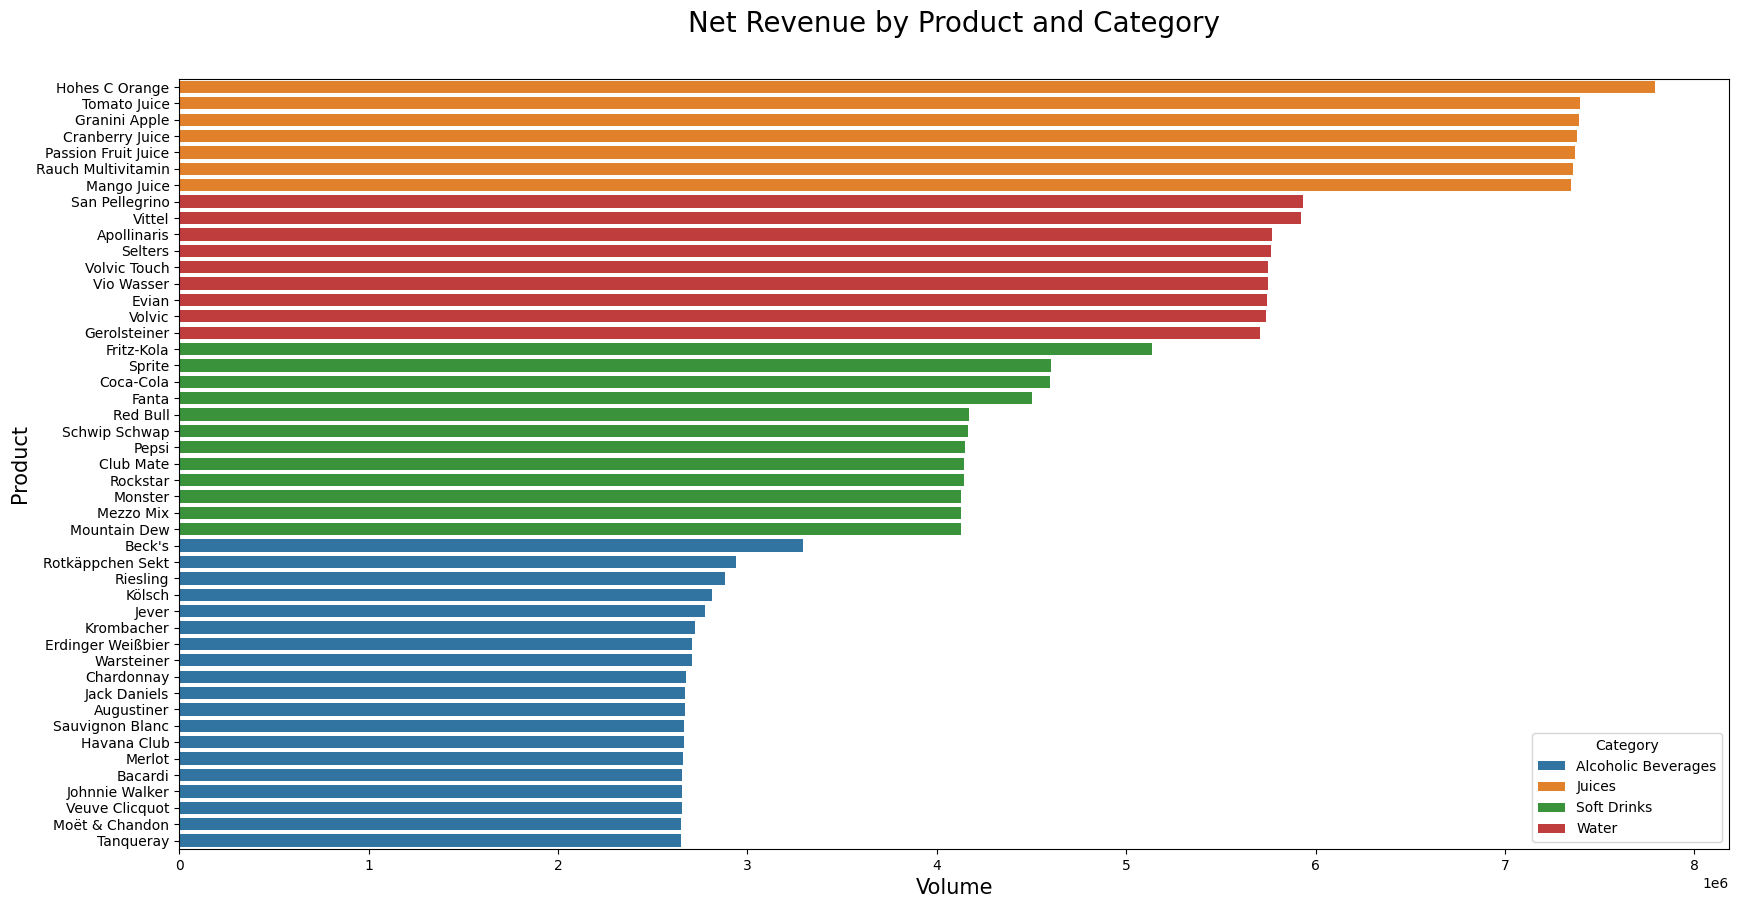

In [31]:
plt.figure(figsize = (20,10))
vol_rev_plot = sns.barplot(volume_by_product_and_category, y="Product",x="Volume_by_Product_and_Category", hue="Category",hue_order=['Alcoholic Beverages', 'Juices', 'Soft Drinks', 'Water'], width=0.75)
vol_rev_plot.set_xlabel('Volume', fontsize=15)
vol_rev_plot.set_ylabel('Product', fontsize=15)
plt.title('Net Revenue by Product and Category', y=1.05, fontsize=20)
plt.show()

### - Performance Per SKU

In [32]:
sku_metrics = (

    df.groupby(["Product"])
        .agg(
            Total_Revenue = ("Total_Price", "sum"),
            Total_Volume = ("Quantity" ,"sum"),
            Order_Reach = ("Order_ID", "nunique"),
            Customer_Reach = ("Customer_ID", "nunique") )
    .reset_index()
)

sku_metrics['Price_Per_Unit'] = sku_metrics['Total_Revenue'] / sku_metrics['Total_Volume']


In [33]:
sku_metrics.sort_values(by="Total_Revenue", ascending=False)

,Product,Total_Revenue,Total_Volume,Order_Reach,Customer_Reach,Price_Per_Unit
41,Veuve Clicquot,202581898.42,2653478,114864,10000,76.35
26,Moët & Chandon,175088086.21,2651599,114907,10000,66.03
18,Johnnie Walker,97261800.90,2654584,115085,10000,36.64
16,Jack Daniels,95881002.87,2668919,115343,10000,35.93
39,Tanqueray,86143655.59,2651287,115189,10000,32.49
2,Bacardi,58467504.37,2656739,114968,10000,22.01
14,Havana Club,58046964.24,2663185,115432,10000,21.80
35,Sauvignon Blanc,23319175.06,2664526,115150,10000,8.75
7,Cranberry Juice,23044830.98,7380841,319328,10000,3.12
31,Riesling,22661280.64,2884347,124557,10000,7.86


---

# 4. Analysis

## Q1: Product Roles

In [34]:
price_median = sku_metrics['Price_Per_Unit'].median()
volume_median = sku_metrics['Total_Volume'].median()


In [35]:
def classify_role(row):
    high_volume = row['Total_Volume'] > volume_median
    high_price = row['Price_Per_Unit'] > price_median

    if high_volume and high_price:
        return "Class 1: Core Profit Driver"
    elif high_volume and not high_price:
        return "Class 2: Traffic Driver"
    elif not high_volume and high_price:
        return "Class 3: Premium Niche"
    else:
        return "Class 4: Low-Value Tail"

sku_metrics["Role"] = sku_metrics.apply(classify_role, axis=1)

In [36]:
sku_metrics.sort_values(by='Role').reset_index(level=0, drop=True)

,Product,Total_Revenue,Total_Volume,Order_Reach,Customer_Reach,Price_Per_Unit,Role
0,Red Bull,10582922.77,4167987,179748,10000,2.54,Class 1: Core Profit Driver
1,Rauch Multivitamin,18109425.51,7361875,318538,10000,2.46,Class 1: Core Profit Driver
2,Passion Fruit Juice,22143146.68,7372320,318923,10000,3.00,Class 1: Core Profit Driver
3,Cranberry Juice,23044830.98,7380841,319328,10000,3.12,Class 1: Core Profit Driver
4,Mango Juice,22391933.19,7349108,317764,10000,3.05,Class 1: Core Profit Driver
5,Tomato Juice,19758646.12,7395329,318773,10000,2.67,Class 1: Core Profit Driver
6,Fritz-Kola,11601174.93,5138738,221258,10000,2.26,Class 1: Core Profit Driver
7,Apollinaris,5137739.74,5770570,248642,10000,0.89,Class 2: Traffic Driver
8,Schwip Schwap,4336382.01,4166595,179815,10000,1.04,Class 2: Traffic Driver
9,San Pellegrino,5188405.23,5934719,256068,10000,0.87,Class 2: Traffic Driver


In [37]:
#top_twenty_percent = sku_metrics2.loc[sku_metrics2['Revenue_Percentile_Rank'] >= 80]
#bottom_twenty_percent = sku_metrics2.loc[sku_metrics2['Revenue_Percentile_Rank'] <= 80]

In [38]:
#top_twenty_profit_margin = (top_twenty_percent['Total_Revenue'].sum() / sku_metrics2['Total_Revenue'].sum()) * 100
#top_twenty_profit_margin

- 71% of revenue comes from the top 20% of SKUs

## Q2: *Which SKUs show strong and consistent revenue performance and positive growth trends?*

#### - Time Series Aggregation (Monthly)

In [39]:
monthly_product = (

    df.groupby(["Product", "YearMonth"])
        .agg(
            Total_Revenue = ("Total_Price", "sum"),
            Total_Volume = ("Quantity" ,"sum"),
            Order_Reach = ("Order_ID", "nunique"),
            Customer_Reach = ("Customer_ID", "nunique") )
    .reset_index()
)



In [40]:
monthly_product.head()

,Product,YearMonth,Total_Revenue,Total_Volume,Order_Reach,Customer_Reach
0,Apollinaris,2021-01,140898.68,162073,6953,4995
1,Apollinaris,2021-02,129300.37,149261,6421,4728
2,Apollinaris,2021-03,143474.45,165899,7059,5055
3,Apollinaris,2021-04,136591.50,157583,6826,4954
4,Apollinaris,2021-05,138382.30,161731,7028,5018


In [41]:
monthly_product_pivot = monthly_product.pivot_table(index=["Product", "YearMonth"])

In [42]:
monthly_product_pivot.head()

Customer_Reach  Order_Reach  Total_Revenue  \
Product     YearMonth                                               
Apollinaris 2021-01           4995.00      6953.00      140898.68   
            2021-02           4728.00      6421.00      129300.37   
            2021-03           5055.00      7059.00      143474.45   
            2021-04           4954.00      6826.00      136591.50   
            2021-05           5018.00      7028.00      138382.30   

                       Total_Volume  
Product     YearMonth                
Apollinaris 2021-01       162073.00  
            2021-02       149261.00  
            2021-03       165899.00  
            2021-04       157583.00  
            2021-05       161731.00

In [43]:
product_revenue = (

    monthly_product.groupby('Product', as_index=False)['Total_Revenue']
    .sum()
    .sort_values('Total_Revenue', ascending=False)

)

In [44]:
product_revenue['cumulative_revenue_share'] = (

    product_revenue['Total_Revenue'].cumsum() / product_revenue['Total_Revenue'].sum()
    
)

In [45]:
product_revenue.Product.count()

np.int64(47)

In [46]:
teir1_products = product_revenue.loc[product_revenue['cumulative_revenue_share'] <= 0.80, 'Product']

In [47]:
teir1_data = monthly_product[
    monthly_product['Product'].isin(teir1_products)
    ].copy()

In [48]:
# Ensure each product has enough data (atleast 6 months worth)

min_months = 6

validate_products = (
    teir1_data.groupby('Product')['YearMonth']
    .nunique()
    .loc[lambda x: x>= min_months]
    .index
)

teir1_data = teir1_data[teir1_data['Product'].isin(validate_products)]

In [49]:
# Calculate raw MoM

teir1_data.groupby(['Product', 'YearMonth'])

teir1_data['mom_revenue_growth'] = (
    teir1_data.groupby('Product')['Total_Revenue'].pct_change()
)

In [50]:
# smoothing raw MoM

teir1_data['mom_revenue_growth_2m_avg'] = (
    teir1_data.groupby('Product')['mom_revenue_growth']
    .rolling(2)
    .mean()
    .reset_index(level=0, drop=True)
)

In [51]:
teir1_data.Product.value_counts()

Product
Bacardi                36
Chardonnay             36
Cranberry Juice        36
Havana Club            36
Jack Daniels           36
Johnnie Walker         36
Mango Juice            36
Merlot                 36
Moët & Chandon         36
Passion Fruit Juice    36
Riesling               36
Sauvignon Blanc        36
Tanqueray              36
Veuve Clicquot         36
Name: count, dtype: int64

---

In [52]:
teir1_data.iloc[288:324]

,Product,YearMonth,Total_Revenue,Total_Volume,Order_Reach,Customer_Reach,mom_revenue_growth,mom_revenue_growth_2m_avg
936,Moët & Chandon,2021-01,4865091.39,75883,3287,2788,NaN,NaN
937,Moët & Chandon,2021-02,4154968.80,65298,2855,2490,-0.15,NaN
938,Moët & Chandon,2021-03,4978691.43,78861,3314,2835,0.20,0.03
939,Moët & Chandon,2021-04,4588760.66,72040,3074,2660,-0.08,0.06
940,Moët & Chandon,2021-05,4525786.64,71935,3221,2771,-0.01,-0.05
941,Moët & Chandon,2021-06,4450150.88,71129,3128,2682,-0.02,-0.02
942,Moët & Chandon,2021-07,4721930.61,74881,3242,2777,0.06,0.02
943,Moët & Chandon,2021-08,4869234.19,77078,3323,2835,0.03,0.05
944,Moët & Chandon,2021-09,4540976.09,72494,3093,2674,-0.07,-0.02
945,Moët & Chandon,2021-10,4792945.74,75351,3290,2806,0.06,-0.01


In [53]:
# Linear Regression Model

X = np.arange(36).reshape(-1,1)
y = teir1_data['Total_Revenue'].iloc[288:324]


In [54]:
model = LinearRegression()
model.fit(X,y)
slope = model.coef_[0]

In [55]:
slope

np.float64(14590.768469755465)

In [56]:
avg_growth = slope / y.mean()
avg_growth

np.float64(0.003000019454671477)

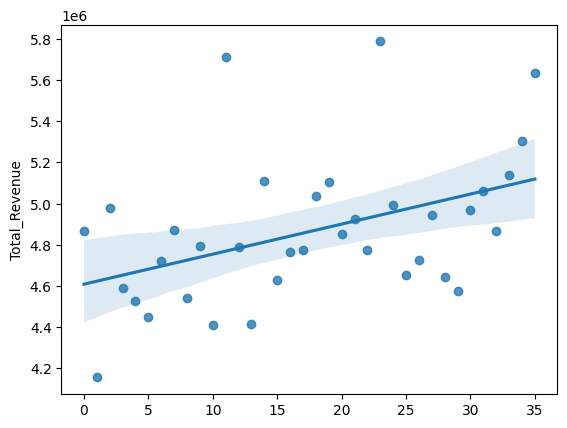

In [57]:
sns.regplot(x= X , y=y)
plt.show()

___

In [58]:
def lin_reg_growth(df_group):
    y = df_group['Total_Revenue'].values
    X = np.arange(len(y)).reshape(-1,1)
    model = LinearRegression()
    model.fit(X,y)
    slope = model.coef_[0] 
    return slope


avg_monthly_revenue_inc = teir1_data.groupby('Product').apply(lin_reg_growth, include_groups=False)

In [59]:
average_monthly_revenue_increase = pd.DataFrame(avg_monthly_revenue_inc)

In [60]:
average_monthly_revenue_increase.rename(columns={'Product':'Product', 0:'Avg_Monthly_Rev_Increase'}, inplace=True)

In [61]:
average_monthly_revenue_increase.sort_values(by="Avg_Monthly_Rev_Increase", ascending=False)

,Avg_Monthly_Rev_Increase
Product,
Moët & Chandon,14590.77
Veuve Clicquot,10124.19
Johnnie Walker,6423.00
Jack Daniels,6249.01
Tanqueray,5849.80
Havana Club,4203.14
Bacardi,3198.21
Chardonnay,2203.37
Riesling,1771.65


In [62]:
def log_reg_growth(group):
    y_log = np.log1p(group['Total_Revenue'].values)
    X = np.arange(len(y)).reshape(-1,1)
    model = LinearRegression()
    model.fit(X,y_log)
    log_slope = model.coef_[0]
    growth_rate = np.exp(log_slope) - 1
    return (growth_rate * 1000)

avg_monthly_revenue_growth_pct = teir1_data.groupby('Product').apply(log_reg_growth, include_groups=False)

In [63]:
avg_monthly_revenue_growth_pct = pd.DataFrame(avg_monthly_revenue_growth_pct).rename(columns={'Product':'Product', 0:'Avg_Monthly_Rev_Pct_Growth'})

In [64]:
avg_monthly_revenue_growth_pct.sort_values(by="Avg_Monthly_Rev_Pct_Growth", ascending = False)

,Avg_Monthly_Rev_Pct_Growth
Product,
Chardonnay,3.81
Moët & Chandon,3.02
Riesling,2.80
Passion Fruit Juice,2.64
Havana Club,2.63
Mango Juice,2.55
Tanqueray,2.48
Merlot,2.44
Johnnie Walker,2.41


---

## Q2: *How do B2B and B2C purchasing behaviors differ, given B2B operates on a discount pricing model?*

In [65]:
b2b = df[df['Customer_Type'] == 'B2B'].copy()
b2b['discounted'] = b2b['Discount'] > 0.0

b2c = df[df['Customer_Type'] == 'B2C'].copy()
b2c['discounted'] = b2c['Discount'] < 0.0


In [66]:
b2b.discounted.value_counts()

discounted
True    3204505
Name: count, dtype: int64

In [67]:
b2c.discounted.value_counts()

discounted
False    5795405
Name: count, dtype: int64

In [68]:
print(b2b.shape, b2c.shape)

(3204505, 13) (5795405, 13)


### Order Level behavior differences

In [69]:
order_metrics = (
    df.groupby(['Order_ID', 'Customer_Type'])
        .agg(
            total_revenue = ('Total_Price', 'sum'),
            units = ('Quantity', "sum"),
            products = ('Product', "nunique")
        )
        .reset_index()    
    )


In [70]:
order_metrics.head()

,Order_ID,Customer_Type,total_revenue,units,products
0,ORD1,B2B,485.06,310,5
1,ORD10,B2B,301.74,196,3
2,ORD100,B2C,6.91,6,2
3,ORD1000,B2B,1018.33,161,4
4,ORD10000,B2C,74.70,53,5


<Axes: xlabel='Customer_Type', ylabel='units'>

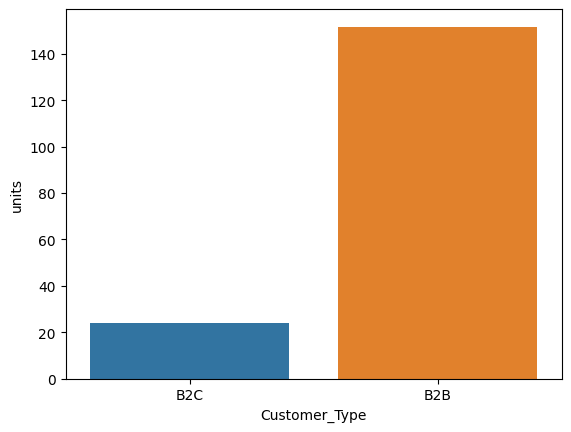

In [71]:
sns.barplot(order_metrics, x = 'Customer_Type', y='units', hue='Customer_Type', order=['B2C', 'B2B'], hue_order=['B2C', 'B2B'])

In [72]:
customer_metrics = (
    df.groupby(['Customer_ID', 'Customer_Type'])
        .agg(
            total_revenue = ('Total_Price', 'sum'),
            units = ('Quantity', "sum"),
            products = ('Product', "nunique")
        )
        .reset_index()    
    )

In [73]:
customer_metrics.head()

,Customer_ID,Customer_Type,total_revenue,units,products
0,CUS1,B2C,38904.13,7508,47
1,CUS10,B2C,40288.83,6910,47
2,CUS100,B2C,36039.74,7163,47
3,CUS1000,B2B,271186.90,44318,47
4,CUS10000,B2B,253436.72,46184,47


<Axes: xlabel='Customer_Type', ylabel='total_revenue'>

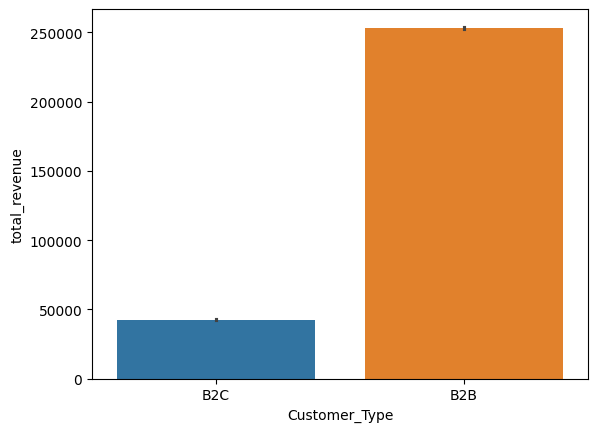

In [74]:
sns.barplot(customer_metrics, x='Customer_Type', y = 'total_revenue', hue='Customer_Type')

## Q3: *Which regions perform best in sales?*

In [75]:
revenue_by_region = df.pivot_table(values=['Total_Price'], index=['Region'], aggfunc = {'Total_Price' : 'sum'})

In [76]:
revenue_by_region.sort_values(by=['Total_Price'], ascending= False, inplace=True)

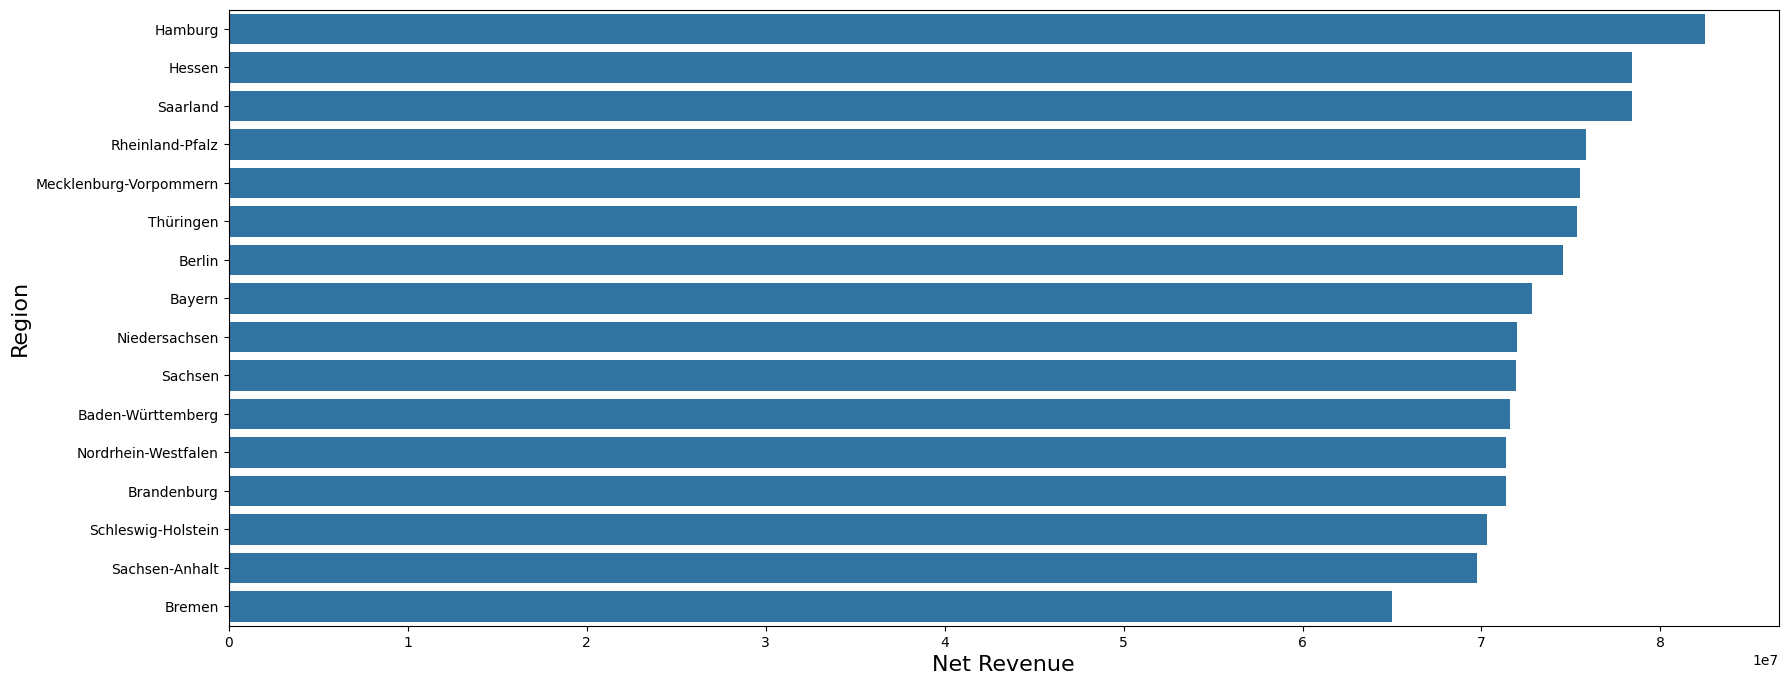

In [77]:
plt.figure(figsize=(20,8))
rev_by_region = sns.barplot(revenue_by_region, y='Region', x='Total_Price')
rev_by_region.set_xlabel('Net Revenue', fontsize=16)
rev_by_region.set_ylabel('Region', fontsize=16)
#plt.ticklabel_format(style='plain')
plt.show()

## Q4: *How does average order value vary by product category?*

In [78]:
category_metrics = (

    df.groupby(["Category"])
    .agg(
        total_sales_revenue = ("Total_Price", "sum"),
        total_orders = ("Order_ID", "count")
    ).reset_index()

    
)

In [79]:
category_metrics

,Category,total_sales_revenue,total_orders
0,Alcoholic Beverages,911797919.72,2251625
1,Juices,133167848.64,2249937
2,Soft Drinks,82802542.53,2248131
3,Water,48912852.46,2250217


In [80]:
category_metrics["AOV"] = category_metrics["total_sales_revenue"]/category_metrics["total_orders"]

In [81]:
category_metrics

,Category,total_sales_revenue,total_orders,AOV
0,Alcoholic Beverages,911797919.72,2251625,404.95
1,Juices,133167848.64,2249937,59.19
2,Soft Drinks,82802542.53,2248131,36.83
3,Water,48912852.46,2250217,21.74


# Sales Forecasting

In [82]:
ts_df = df[['Order_Date', 'Order_ID', 'Total_Price']]

#ts_df = ts_df.rename(columns={'Order_Date': 'ds', 'Order_ID': 'unique_id', 'Total_Price': 'y'})

In [83]:
ts_df.head()

,Order_Date,Order_ID,Total_Price
0,2023-08-23,ORD1,79.18
1,2023-08-23,ORD1,126.36
2,2023-08-23,ORD1,81.14
3,2023-08-23,ORD1,170.98
4,2023-08-23,ORD1,27.40


In [84]:
daily_sales = ts_df.groupby('Order_Date').agg(total_sales = ("Total_Price", 'sum')).reset_index()

In [85]:
daily_sales["time"] = daily_sales.index
daily_sales.head()

,Order_Date,total_sales,time
0,2021-01-01,987429.55,0
1,2021-01-02,1067311.95,1
2,2021-01-03,964076.37,2
3,2021-01-04,1033108.49,3
4,2021-01-05,1083223.79,4


<Axes: >

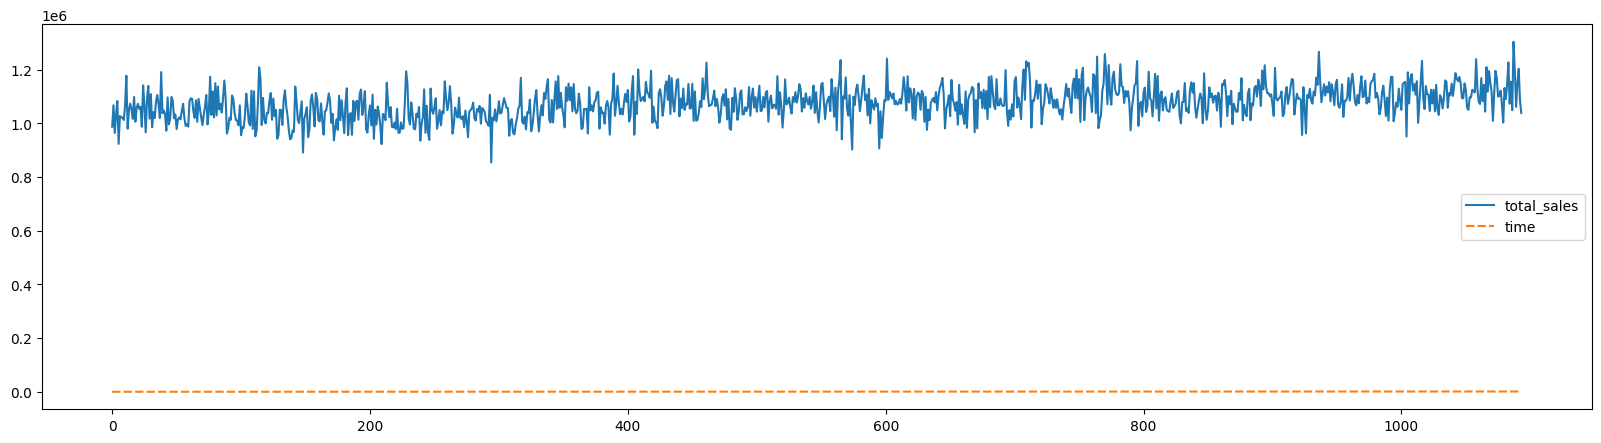

In [86]:
plt.figure(figsize=(20,5))
sns.lineplot(daily_sales)

In [87]:
ds_log = daily_sales
ds_log['total_sales'] = np.log(ds_log['total_sales'])
ds_log.head()

,Order_Date,total_sales,time
0,2021-01-01,13.80,0
1,2021-01-02,13.88,1
2,2021-01-03,13.78,2
3,2021-01-04,13.85,3
4,2021-01-05,13.90,4


<Axes: >

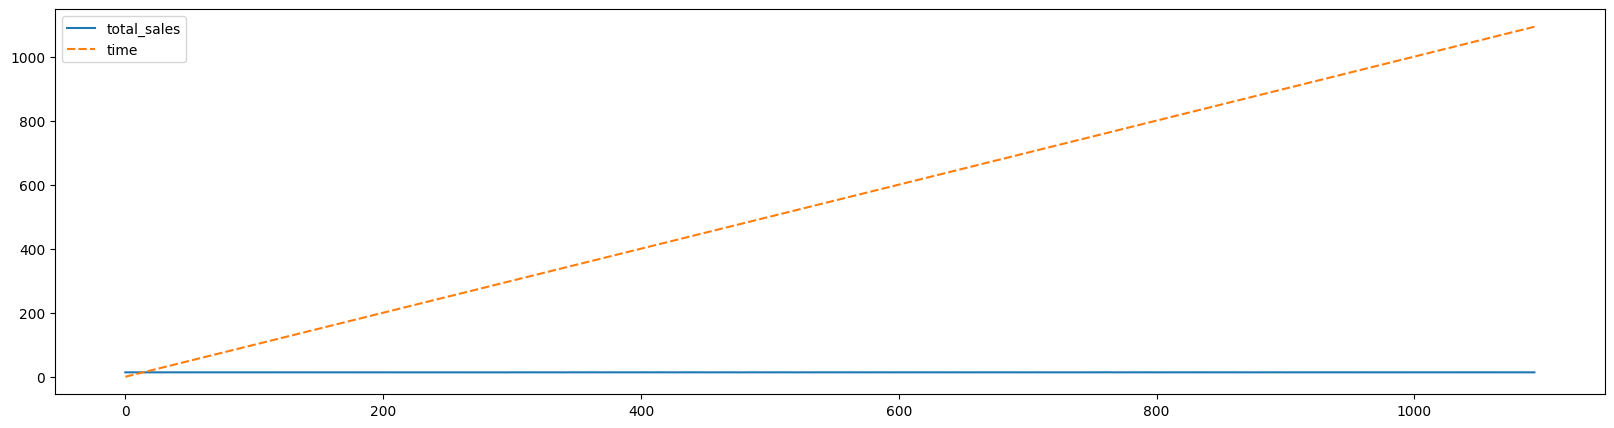

In [88]:
plt.figure(figsize=(20,5))
sns.lineplot(ds_log)

In [89]:
msk = (daily_sales.index < len(daily_sales)-30)
df_train = daily_sales[msk].copy()
df_test = daily_sales[~msk].copy()

### check if time series is stationary

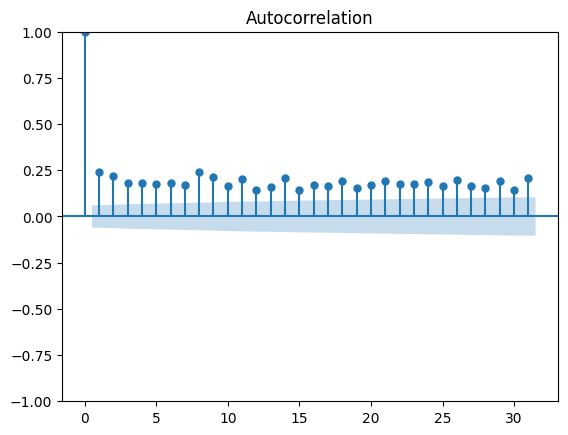

In [90]:
from statsmodels.graphics.tsaplots  import plot_acf, plot_pacf

acf_original = plot_acf(df_train["total_sales"])

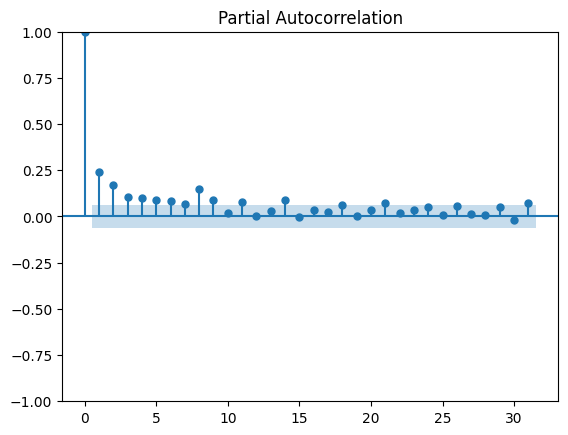

In [91]:
pacf_original = plot_pacf(df_train["total_sales"])

In [92]:
from statsmodels.tsa.stattools import adfuller
adf_test = adfuller(df_train["total_sales"], autolag="AIC")
print(adf_test[1])

0.03000299657249609


- According to our tests we can conclude the sales data is stationary and non-autocorrelated. this means there are no significant trends, seasonality, or variance and the data should be treated an unpredictable and white noise. This ofcourse is not realistic real world data. That being said we can still use a handful of predictions models for our data.

### Label Encoding

In [132]:
from sklearn.preprocessing import LabelEncoder

In [162]:
ml_df = df.drop(columns=["Order_ID", "Customer_ID", "YearMonth", "Order_Date"])
ml_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8999910 entries, 0 to 8999909
Data columns (total 8 columns):
 #   Column         Dtype  
---  ------         -----  
 0   Customer_Type  object 
 1   Product        object 
 2   Category       object 
 3   Unit_Price     float64
 4   Quantity       int64  
 5   Discount       float64
 6   Total_Price    float64
 7   Region         object 
dtypes: float64(3), int64(1), object(4)
memory usage: 549.3+ MB


In [164]:
label_encoder = LabelEncoder()
ml_df["Customer_Type"] = label_encoder.fit_transform(ml_df["Customer_Type"])
ml_df["Product"] = label_encoder.fit_transform(ml_df["Product"])
ml_df["Category"] = label_encoder.fit_transform(ml_df["Category"])
ml_df["Region"] = label_encoder.fit_transform(ml_df["Region"])
#ml_df["Order_Date"] = label_encoder.fit_transform(ml_df["Order_Date"])

In [165]:
ml_df.head()

,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region
0,0,42,3,1.66,53,0.10,79.18,0
1,0,9,3,1.56,90,0.10,126.36,0
2,0,38,2,1.17,73,0.05,81.14,0
3,0,29,1,3.22,59,0.10,170.98,0
4,0,12,3,0.87,35,0.10,27.40,0


### Test / Train Split

In [166]:
from sklearn.model_selection import train_test_split

In [167]:
X = ml_df.drop(columns=["Total_Price"])
y = ml_df["Total_Price"]

In [176]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.1, random_state=45)
print(X_train.shape, X_test.shape)

(8099919, 7) (899991, 7)


### Linear Regression

In [177]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score 

In [178]:
lr = LinearRegression()
lr_model = lr.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

In [179]:
lr_mse = mean_squared_error(y_test, y_pred)
lr_r2 = r2_score(y_test, y_pred)
print("MSE: ", lr_mse, " ", "R2: ", lr_r2)

MSE:  136098.42570221794   R2:  0.4785987536859053


In [180]:
# sns.regplot(data=daily_sales,x="time", y="total_sales", line_kws=dict(color="r"), marker="x")

### KNN

In [181]:
from sklearn.neighbors import KNeighborsRegressor

In [182]:
knn = KNeighborsRegressor()
knn_model = knn.fit(X_train, y_train)
y_pred = knn_model.predict(X_test)

In [183]:
knn_mse = mean_squared_error(y_test, y_pred)
knn_r2 = r2_score(y_test, y_pred)
print("MSE: ", knn_mse, " ", "R2: ", knn_r2)

MSE:  353.0727759885509   R2:  0.998647356980875
